# Notebook para utilizar el modelo de clasificación y segmentación de anillos

Código realizado por:
- DOMÉNICO MORALES ORTIZ 		A00820324 a00820324@tec.mx

- MÓNICA DODERO ARROYO		    A01795330 a01795330@tec.mx

- OSCAR ANTONIO SUÁREZ V 	    A01323987 a01323987@tec.mx

INSTITUTO TECNOLÓGICO Y DE ESTUDIOS SUPERIORES DE MONTERREY
TC5035 - Proyecto Integrador

Dra. Grettel Barceló Alonso

Dr. Luis Eduardo Falcón Morales

Mtra. Verónica Sandra Guzmán de Valle

## Parámetros ingresados por el usuario

In [ ]:
COLAB = False
NOTEBOOK_PATH = r'/content/drive/MyDrive/Proyecto Integrador/Codigo'
CORRER_CLASIFICACION = False   # True o False
CORRER_SEGMENTACION = True    # True o False

# Configuración de clasificación
MODELO = 'DINOv2ViTBase'                                                # 'DINOv2ViTBase' o 'EfficientNetB6
PREPROCESAMIENTO = 'rgi_stack'                                          # 'rgi_stack' o 'rgi_unsharp_mask'
RUTA_FITS = r'C:\MNA\MNA-V\Proyecto Integrador\notebooks\ls_fits_test'  # Ruta de la carpeta donde se encuentren las imágenes fits a inferenciar
RUTA_MODELOS = r'C:\MNA\MNA-V\Proyecto Integrador\notebooks\models'     # Ruta donde se encuentran los modelos
FORMATO_GUARDADO = 'all'                                                  # 'fits' o 'png'
THRESHOLD = 0.5                                                         # Umbral para clasificar una imagen

# Configuración de segmentación
RUTA_ARCHIVO_FITS = r'C:\MNA\MNA-V\Proyecto Integrador\notebooks\inference_DINOv2ViTBase_rgi_stack\run_002\predicts\rings\fits\SDSS_1237651271350419694_inner+outer_ra129.875900_dec52.167705_s224.fits'
TIPO_ANILLO = 'inner+outer'  # 'inner' o 'outer' o 'inner+outer'
MOSTRAR_MASCARA = False  # True o False
VISUALIZAR_SEGMENTACION = True  # True o False

## Instalación de módulos y referencias de librerías

In [ ]:
if COLAB:
    !pip install astropy
    from google.colab import drive
    drive.mount('/content/drive')
    # change cwd to notebook_path
    import os
    os.chdir(NOTEBOOK_PATH)
    print(f"The current notebook path is: {os.getcwd()}")

NameError: name 'COLAB' is not defined

In [3]:
import helpers
from pathlib import Path

## Inferencia de clasificación

In [4]:
if CORRER_CLASIFICACION:
    runs_dir = helpers.classification_inference(PREPROCESAMIENTO, MODELO, RUTA_FITS, RUTA_MODELOS, FORMATO_GUARDADO, THRESHOLD)

## Inferencia de segmentación

Creando directorio de segmentaciones en inference_segmentations
CONFIG: Usando archivo SDSS_1237651271350419694_inner+outer_ra129.875900_dec52.167705_s224.fits
CONFIG: Buscando anillos de tipo inner+outer
=== Generando segmentación y mediciones...
Anillo outer encontrado!
=== Mediciones guardadas en: inference_segmentations\segmentation_results.csv
Anillo inner encontrado!
=== Mediciones guardadas en: inference_segmentations\segmentation_results.csv
=== Segmentación guardada en: inference_segmentations\segmentations


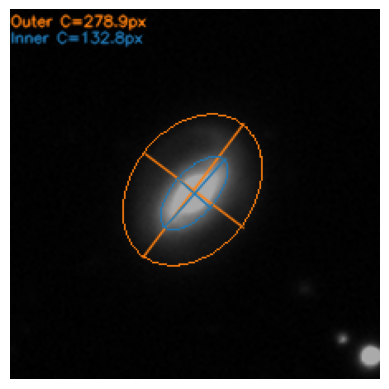

In [5]:
try:
    runs_dir.exists()
except:
    runs_dir = Path('inference_segmentations')
    runs_dir.mkdir(parents=True, exist_ok=True)
    print(f'Creando directorio de segmentaciones en {runs_dir}')

helpers.ring_segmentation_inference(RUTA_ARCHIVO_FITS, TIPO_ANILLO, MOSTRAR_MASCARA, runs_dir, VISUALIZAR_SEGMENTACION)